In [2]:
# load libs
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

In [4]:
# Adjust path if needed
file_path = "../data/final_dataset/gwas_adjpval/gwaspadj.assoc.linear"
# Only load needed columns: CHR, BP, SNP, P
usecols = ['CHR', 'BP', 'SNP', 'P']
df = pd.read_csv(file_path, delim_whitespace=True, usecols=usecols)

In [ ]:
# Drop rows with missing P-values immediately
df.dropna(subset=['P'], inplace=True)

# Convert chromosomes to numeric (X, Y, MT)
df['CHR'] = df['CHR'].replace({'X': 23, 'Y': 24, 'MT': 25})
df = df[df['CHR'].notna()]
df['CHR'] = df['CHR'].astype(int)

# Sort by chromosome and basepair
df = df.sort_values(['CHR', 'BP'])
df['-log10(P)'] = -np.log10(df['P'])

# Genomic inflation factor
chisq = stats.chi2.isf(df['P'], df=1)
lambda_gc = np.median(chisq) / stats.chi2.ppf(0.5, df=1)
print(f"Genomic inflation factor (lambda): {lambda_gc:.3f}")

# GC-adjusted p-values
chisq_gc = chisq / lambda_gc
p_gc = stats.chi2.sf(chisq_gc, df=1)
df['-log10(P_gc)'] = -np.log10(p_gc)


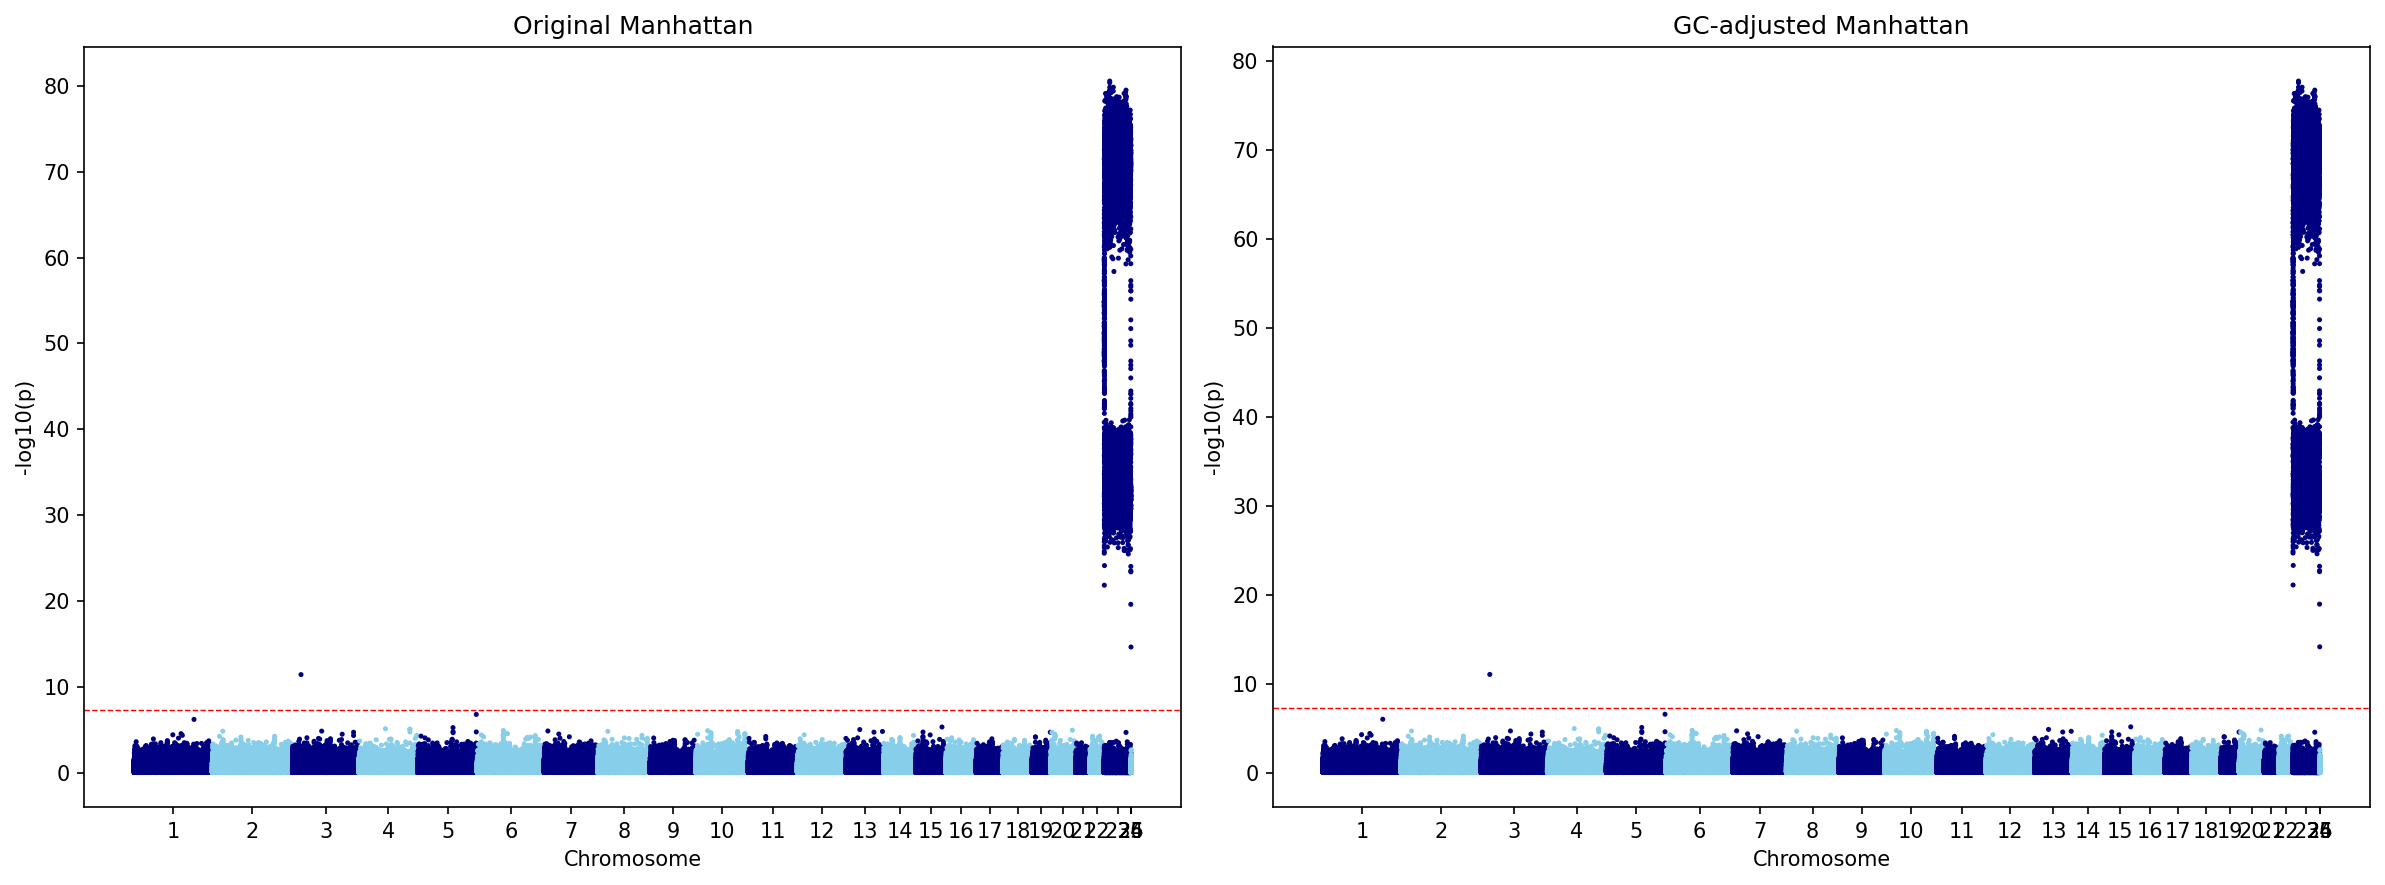

In [7]:
# Manhattan Plot
df['ind'] = range(len(df))
ticks, labels = [], []
for chr_num, group in df.groupby('CHR'):
    ticks.append(group['ind'].median())
    labels.append(str(chr_num))

fig, axs = plt.subplots(1, 2, figsize=(16, 6), dpi=150)

# Manhattan plot (original)
axs[0].scatter(df['ind'], df['-log10(P)'], c=(df['CHR'] % 2).map({0: 'skyblue', 1: 'navy'}), s=2)
axs[0].axhline(-np.log10(5e-8), color='red', linestyle='--', linewidth=0.7)
axs[0].set_title("Original Manhattan")
axs[0].set_xlabel("Chromosome")
axs[0].set_ylabel("-log10(p)")
axs[0].set_xticks(ticks)
axs[0].set_xticklabels(labels)

# Manhattan plot (GC-adjusted)
axs[1].scatter(df['ind'], df['-log10(P_gc)'], c=(df['CHR'] % 2).map({0: 'skyblue', 1: 'navy'}), s=2)
axs[1].axhline(-np.log10(5e-8), color='red', linestyle='--', linewidth=0.7)
axs[1].set_title("GC-adjusted Manhattan")
axs[1].set_xlabel("Chromosome")
axs[1].set_ylabel("-log10(p)")
axs[1].set_xticks(ticks)
axs[1].set_xticklabels(labels)

plt.tight_layout()
plt.show()

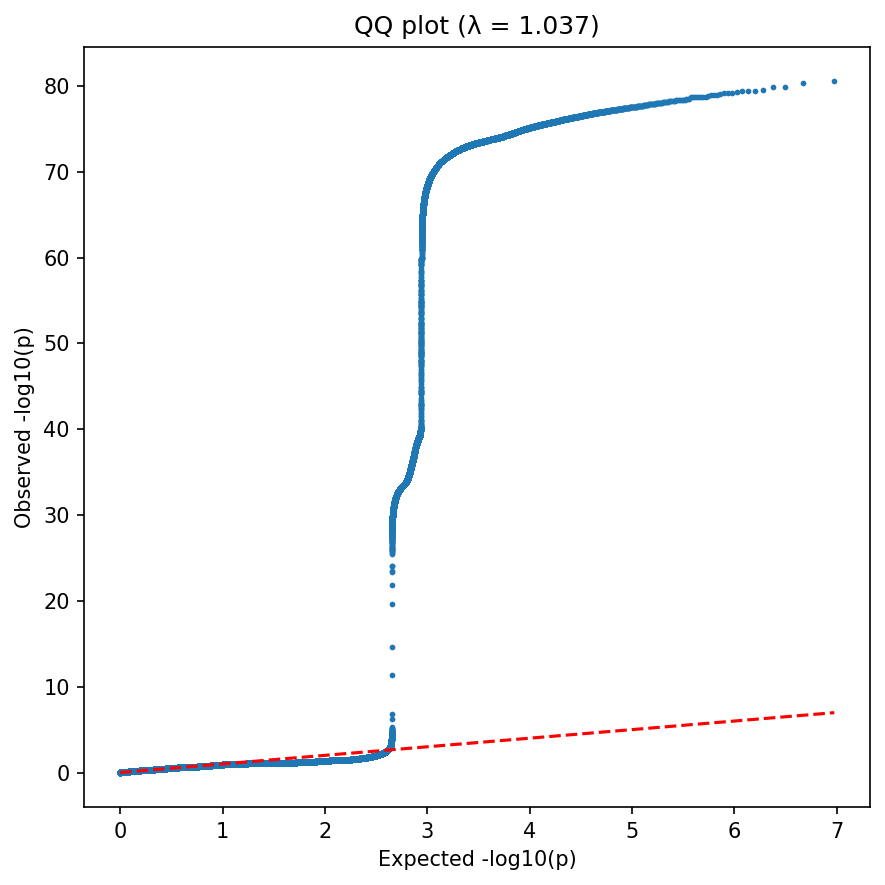

In [6]:
# QQ Plot (original)
expected = -np.log10(np.linspace(1 / len(df), 1, len(df)))
observed = df['-log10(P)'].sort_values(ascending=False).values

plt.figure(figsize=(6, 6), dpi=150)
plt.scatter(expected, observed, s=3)
plt.plot([0, max(expected)], [0, max(expected)], linestyle='--', color='red')
plt.xlabel("Expected -log10(p)")
plt.ylabel("Observed -log10(p)")
plt.title(f"QQ plot (λ = {lambda_gc:.3f})")
plt.tight_layout()
plt.show()

In [36]:
# how many significant loci
significant = df[df['P'] < 5e-8]
print(len(significant))
print(significant['SNP'])

6
1092480     rs1349787
1092509     rs6588911
1092518    rs35178888
1116614      rs306894
1116649     rs3093474
1117147     rs1084422
Name: SNP, dtype: object


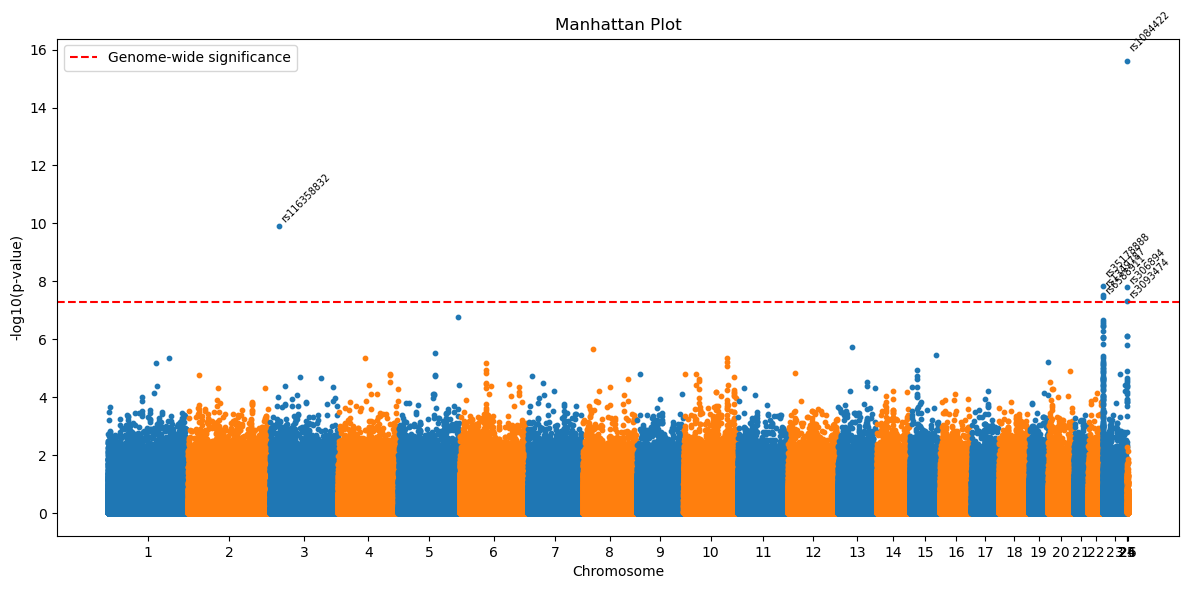

In [4]:
plt.figure(figsize=(12, 6))
colors = ['#1f77b4', '#ff7f0e']
for i, (chr_num, group) in enumerate(df.groupby('CHR')):
    plt.scatter(group['ind'], group['-log10(P)'], 
                color=colors[i % len(colors)], s=10)

# Add significance threshold line
plt.axhline(y=threshold, color='red', linestyle='--', label='Genome-wide significance')

# Annotate significant SNPs with jitter
significant = df[df['-log10(P)'] > threshold]
for _, row in significant.iterrows():
    plt.annotate(row['SNP'],
                 (row['ind'], row['-log10(P)'] + 0.2 + np.random.uniform(-0.2, 0.2)),
                 fontsize=7, rotation=45)

# Fix x-axis
plt.xticks(ticks, labels)
plt.xlabel('Chromosome')
plt.ylabel('-log10(p-value)')
plt.title('Manhattan Plot')
plt.legend()
plt.tight_layout()
plt.show()


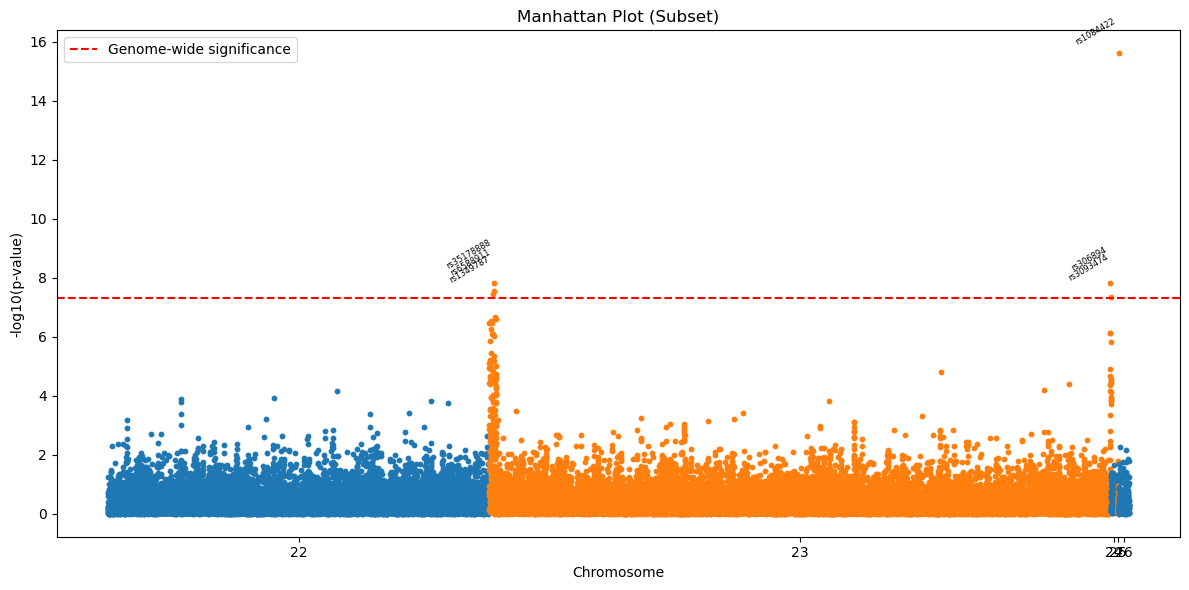

In [34]:
## look specifically at the section around chromosome 22, to get a better look at the variants.

# Filter to chromosomes 20–26 or a specific region
df = df[df['CHR'].between(22, 26)].copy()
# Or for a region: df = df[(df['CHR'] == 22) & (df['BP'].between(30_000_000, 40_000_000))].copy()

# Sort and assign plotting index
df = df.sort_values(['CHR', 'BP'])
df['ind'] = range(len(df))

# Compute ticks for x-axis
ticks = []
labels = []
for chr_num, group in df.groupby('CHR'):
    ticks.append(group['ind'].median())
    labels.append(str(chr_num))

# Plot
plt.figure(figsize=(12, 6))
colors = ['#1f77b4', '#ff7f0e']

for i, (chr_num, group) in enumerate(df.groupby('CHR')):
    plt.scatter(group['ind'], group['-log10(P)'], 
                color=colors[i % len(colors)], s=10)

# Significance threshold
plt.axhline(y=threshold, color='red', linestyle='--', label='Genome-wide significance')

# Annotate top hits
significant = df[df['-log10(P)'] > threshold].nlargest(10, '-log10(P)')
for _, row in significant.iterrows():
    plt.annotate(row['SNP'],
        (row['ind'] + np.random.uniform(-100, 30), row['-log10(P)'] + np.random.uniform(0.3, 0.6)),
        fontsize=6, rotation=30, ha='right', zorder=3)

# Axes
plt.xticks(ticks, labels)
plt.xlabel('Chromosome')
plt.ylabel('-log10(p-value)')
plt.title('Manhattan Plot (Subset)')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
## Now to the QQ Plot

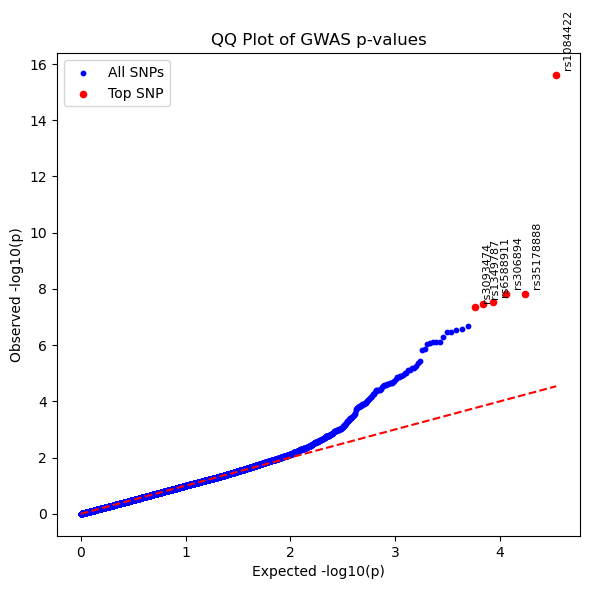

In [42]:
# Remove extremely small or zero p-values to avoid issues with -log10
df = df[df['P'] > 0]

# Sort observed p-values
observed_p = np.sort(df['P'].values)
expected_p = np.linspace(1/len(observed_p), 1, len(observed_p))

# -log10 transform
observed_log = -np.log10(observed_p)
expected_log = -np.log10(expected_p)

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(expected_log, observed_log, c='blue', s=10, label='All SNPs')
plt.plot([0, max(expected_log)], [0, max(expected_log)], color='red', linestyle='--')  # y = x line

# Highlight and annotate top 5 SNPs
top_snps = df.nsmallest(6, 'P')
for _, row in top_snps.iterrows():
    obs_log = -np.log10(row['P'])
    exp_rank = (df['P'] <= row['P']).sum()
    exp_log = -np.log10(exp_rank / len(df))
    plt.scatter(exp_log, obs_log, c='red', s=20, label='Top SNP' if _ == top_snps.index[0] else "")
    plt.annotate(row['SNP'], (exp_log, obs_log), textcoords="offset points", xytext=(5,5), ha='left', fontsize=8, rotation=90)

plt.xlabel('Expected -log10(p)')
plt.ylabel('Observed -log10(p)')
plt.title('QQ Plot of GWAS p-values')
plt.legend()
plt.tight_layout()
plt.show()

## Genomic control λ

In [45]:
# df['P'] = p-values from GWAS
# stats.chi2.isf(p, df=1): finds the chi-squared value that corresponds to that p-value
chisq = stats.chi2.isf(df['P'], df=1)
# this ratio equals lambda
lambda_gc = np.median(chisq) / stats.chi2.ppf(0.5, df=1)
print(f"Genomic inflation factor (lambda): {lambda_gc:.3f}")

Genomic inflation factor (lambda): 0.956


In [46]:
# chisq_gc divides each chi-squared statistic by lambda to "correct" for inflation
chisq_gc = chisq / lambda_gc
p_gc = stats.chi2.sf(chisq_gc, df=1)
print("Most significant GC-adjusted p-value:", p_gc.min())

Most significant GC-adjusted p-value: 5.1859116007633647e-17


In [53]:
df['P_GC'] = stats.chi2.sf(chisq_gc, df=1)
df['-log10(P_GC)'] = -np.log10(df['P_GC'])

## Plot GC-corrected p-values

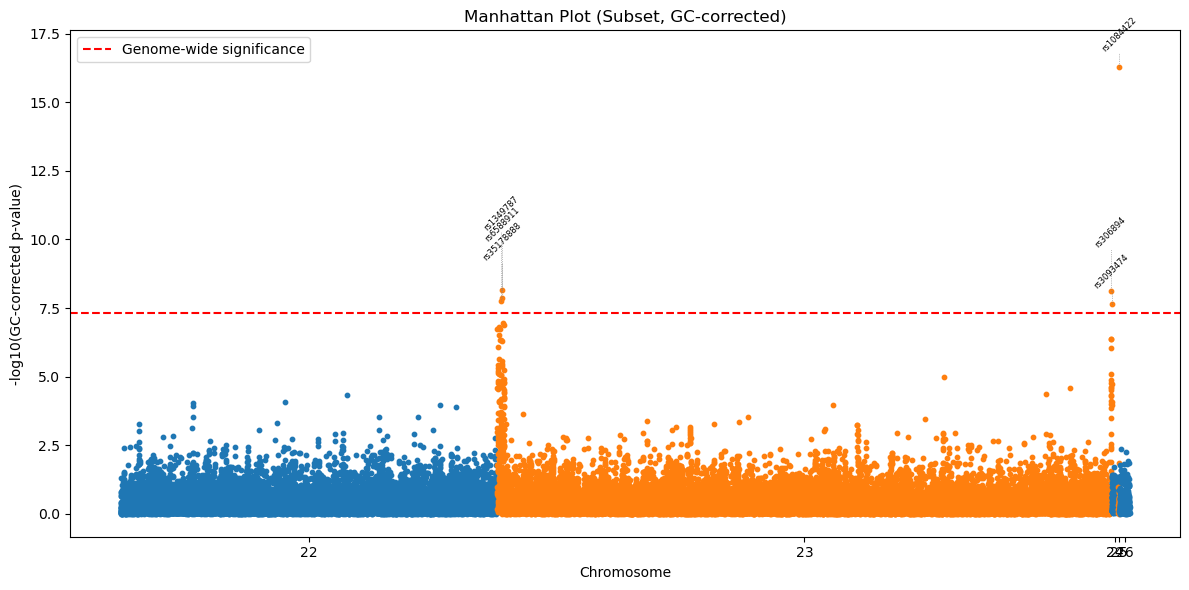

In [60]:
# Filter to chromosomes 22–26
df = df[df['CHR'].between(22, 26)].copy()

# Sort and assign plotting index
df = df.sort_values(['CHR', 'BP'])
df['ind'] = range(len(df))

# Compute ticks for x-axis
ticks = []
labels = []
for chr_num, group in df.groupby('CHR'):
    ticks.append(group['ind'].median())
    labels.append(str(chr_num))

# Plot
plt.figure(figsize=(12, 6))
colors = ['#1f77b4', '#ff7f0e']

for i, (chr_num, group) in enumerate(df.groupby('CHR')):
    plt.scatter(group['ind'], group['-log10(P_GC)'], 
                color=colors[i % len(colors)], s=10)

# Significance threshold
threshold = -np.log10(5e-8)
plt.axhline(y=threshold, color='red', linestyle='--', label='Genome-wide significance')

# Annotate top hits with staggered vertical offsets and connector lines
significant = df[df['-log10(P_GC)'] > threshold].nlargest(10, '-log10(P_GC)')
base_offset = 0.5

for i, (_, row) in enumerate(significant.iterrows()):
    offset = base_offset + (i % 5) * 0.5  # staggered offsets
    x = row['ind']
    y = row['-log10(P_GC)']
    
    # Draw a dotted line from the point to the label
    plt.plot([x, x], [y, y + offset], color='gray', linestyle=':', linewidth=0.5)
    
    # Place the label above the line
    plt.annotate(row['SNP'],
                 (x, y + offset),
                 fontsize=6, rotation=45, ha='center', va='bottom', zorder=3)


# Axes
plt.xticks(ticks, labels)
plt.xlabel('Chromosome')
plt.ylabel('-log10(GC-corrected p-value)')
plt.title('Manhattan Plot (Subset, GC-corrected)')
plt.legend()
plt.tight_layout()
plt.show()